## Bayesian Mincer regression

### Введение

В последнее время набирает обороты дискуссия о деградации российского профессионального образования, инфляции статуса дипломированного специалиста. В условиях рыночной экономики целесообразность получения образования в основном объясняется повышением дохода индивида. При этом совершенно неочевидно, почему, например, рентабельность высшего образования превосходит выгоду от получения среднего профессионального образования. Особенный интерес представляет Россия, в которой за последние годы произошли достаточно серьезные структурные изменения на рынке труда. В частности, можно говорить о высоком спросе на представителей рабочих профессий, доходы которых растут на протяжении последних 4-х лет. Одновременно с этим сохраняется эффект так называемого "российского образовательного проклятия": доступность высшего образования влечет за собой рост предложения рабочей силы с высокой образовательной подготовкой, снижая отдачу от высшего образования. 

### Методология исследования


В современной практике измерение отдачи от вложений в человеческий капитал чаще всего осуществляется путем эконометрического оценивания «минцеровского» уравнения заработков, названного так в честь известного американского экономиста Дж. Минцера. Уравнение минцеровской регрессии принимает вид:

$$ln(W_i) = \alpha_0 + \alpha_1 G_i + \rho_1 L_{1i} + \rho_2 L_{2i} + ... + \rho_k L_{ki} + \beta_1 E_i + \beta_2 E_i^2 + \epsilon_i$$ 
где

$G_i - \text{индикатор пола}, $

$L_1, ... L_k -  \text{дамми-переменные для k выделенных уровней образования}, $

$E - \text{потенциальный опыт},$

$\alpha_0, \alpha_1, \rho_1, ..., \rho_k, \beta_1, \beta_2 - \text{параметры модели}$;




### Обзор данных
В рамках исследования будет использоваться выборочное наблюдение доходов населения и участия в социальных программах (ВНДН) Росстата. Это специализированное обследование, направленное на максимально полное и детализированное измерение доходов российских домохозяйств и их членов.  Ниже перечислены преимущества данного выборочного обследования:
1. проводится ежегодно с 2011г.
2.  охватывает все сектора экономики и все типы занятости
3. информация о заработках собирается не в месячном, а в годовом формате. С учетом высокой волатильности текущих заработков, характерной для российского рынка труда, это существенное преимущество
4. Методология обследования позволяет построить регрессию Минсера

### Описание набора данных



Набор данных ВНДН включает более 60000 наблюдений. В рамках настоящего наблюдения был выделен срез респондентов, которые осуществляют трудовую деятельность по найму. 

**Расшифровка значений переменных**

`R_DEN`   - Денежное вознаграждение до выплаты подоходного налога (по основному месту работы), руб.

`H01_02`  - Возраст респондента

`H01_01`  - Пол респондента

`R_5_1`   - Уровень образования респондентов

`R_7_1_3` - Индикатор занятости респондента по найму


`KVZV`    - вес наблюдения. Сэмпл данного датасета является репрезентативным при условии, что $P(n_i) = KVZV_i$


[Источник](https://tochno.st/datasets/surveys)


Далее мы сконструируем вспомогательные переменные, а также преобразуем исходные переменные, чтобы их вид соответствовал модели

In [1]:
import numpy as np
import arviz as az

import pandas as pd
import polars as pl


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [17]:
# Your path here
path = r'/Users/timurkarsaliev/Yandex.Disk.localized/ВНДН (Выборочное наблюдение доходов населения и участия в социальных программах)/2024/ВНДН_2024_Датасет_по_индивидуальным_данным.csv'

education_level_dict = {
    # R_5_1 : [название уровня образования, кол-во полных лет обучения]
    1: ["Кадры высшей квалификации (послевузовское)", 18] ,
    2: ["Высшее образование (специалитет, магистратура, бакалавриат)", 15],
    3: ["Неполное высшее (незаконченное высшее)", 11],
    4: ["Подготовка специалистов среднего звена (среднее профессиональное)", 13],
    5: ["Подготовка квалифицированных рабочих и служащих (среднее профессиональное)", 12],
    6: ["Среднее общее образование (среднее полное общее)", 11],
    7: ["Основное общее образование (неполное среднее)", 9],
    8: ["Не имеют основного общего образования", 0],
}

df = pd.read_csv(path, sep=';')

# Из анализа исключаются респонденты, которые не имеют основного общего образования
df = df[df['R_5_1'] <= 6].copy()

# Выделяем срез людей, которые работают по найму И имеют образование
clean_df = df.loc[(~df['R_7_1_3'].isnull()) & (~df['R_5_1'].isnull())]

# Название ступени образования
clean_df.loc[:, ['educ']] = clean_df['R_5_1'].apply(lambda x: education_level_dict[x][0] if x else None)
# Переменная  кол-во полных лет обучения
clean_df.loc[:, ['educ_years']] = clean_df['R_5_1'].apply(lambda x: education_level_dict[x][1] if x else None)


In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

regr_df = clean_df.copy()

data = pd.DataFrame()
# Pre-tax wage (yearly)
data['ln_wage'] = np.log(regr_df['R_DEN'])

# Sample weights
weights = regr_df['KVZV']

#Gender: 1 - male, 0 - female
data['gender'] = regr_df['H01_01'].map({1: 1, 2: 0})

# Education
dummies_educ = pd.get_dummies(regr_df['educ'])
data[dummies_educ.columns[:-1]] = dummies_educ.iloc[:, :-1].astype(int)

# save for later
educuation_cols = dummies_educ.columns.tolist()[:-1]
indicator_cols = dummies_educ.columns.tolist() + ['gender']

# Potential experience 
attendance_age = 7
data['exp'] = regr_df['H01_02'] - attendance_age - regr_df['educ_years']
data['exp_sq'] = data['exp'].pow(2)



### EDA

In [19]:
print(f'Кол-во наблюдений в выборке: {data.shape[0]}')
print()

nans = data.isna().mean()
print(30 * '-' + 'Доля NaN значений' + 30 * '-')
print(nans)

Кол-во наблюдений в выборке: 51464

------------------------------Доля NaN значений------------------------------
ln_wage                                                                       0.0
gender                                                                        0.0
Высшее образование (специалитет, магистратура, бакалавриат)                   0.0
Кадры высшей квалификации (послевузовское)                                    0.0
Неполное высшее (незаконченное высшее)                                        0.0
Подготовка квалифицированных рабочих и служащих (среднее профессиональное)    0.0
Подготовка специалистов среднего звена (среднее профессиональное)             0.0
exp                                                                           0.0
exp_sq                                                                        0.0
dtype: float64


/var/folders/py/kfy8hq996jdff24srqr37qsm0000gn/T/ipykernel_49173/1434664750.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


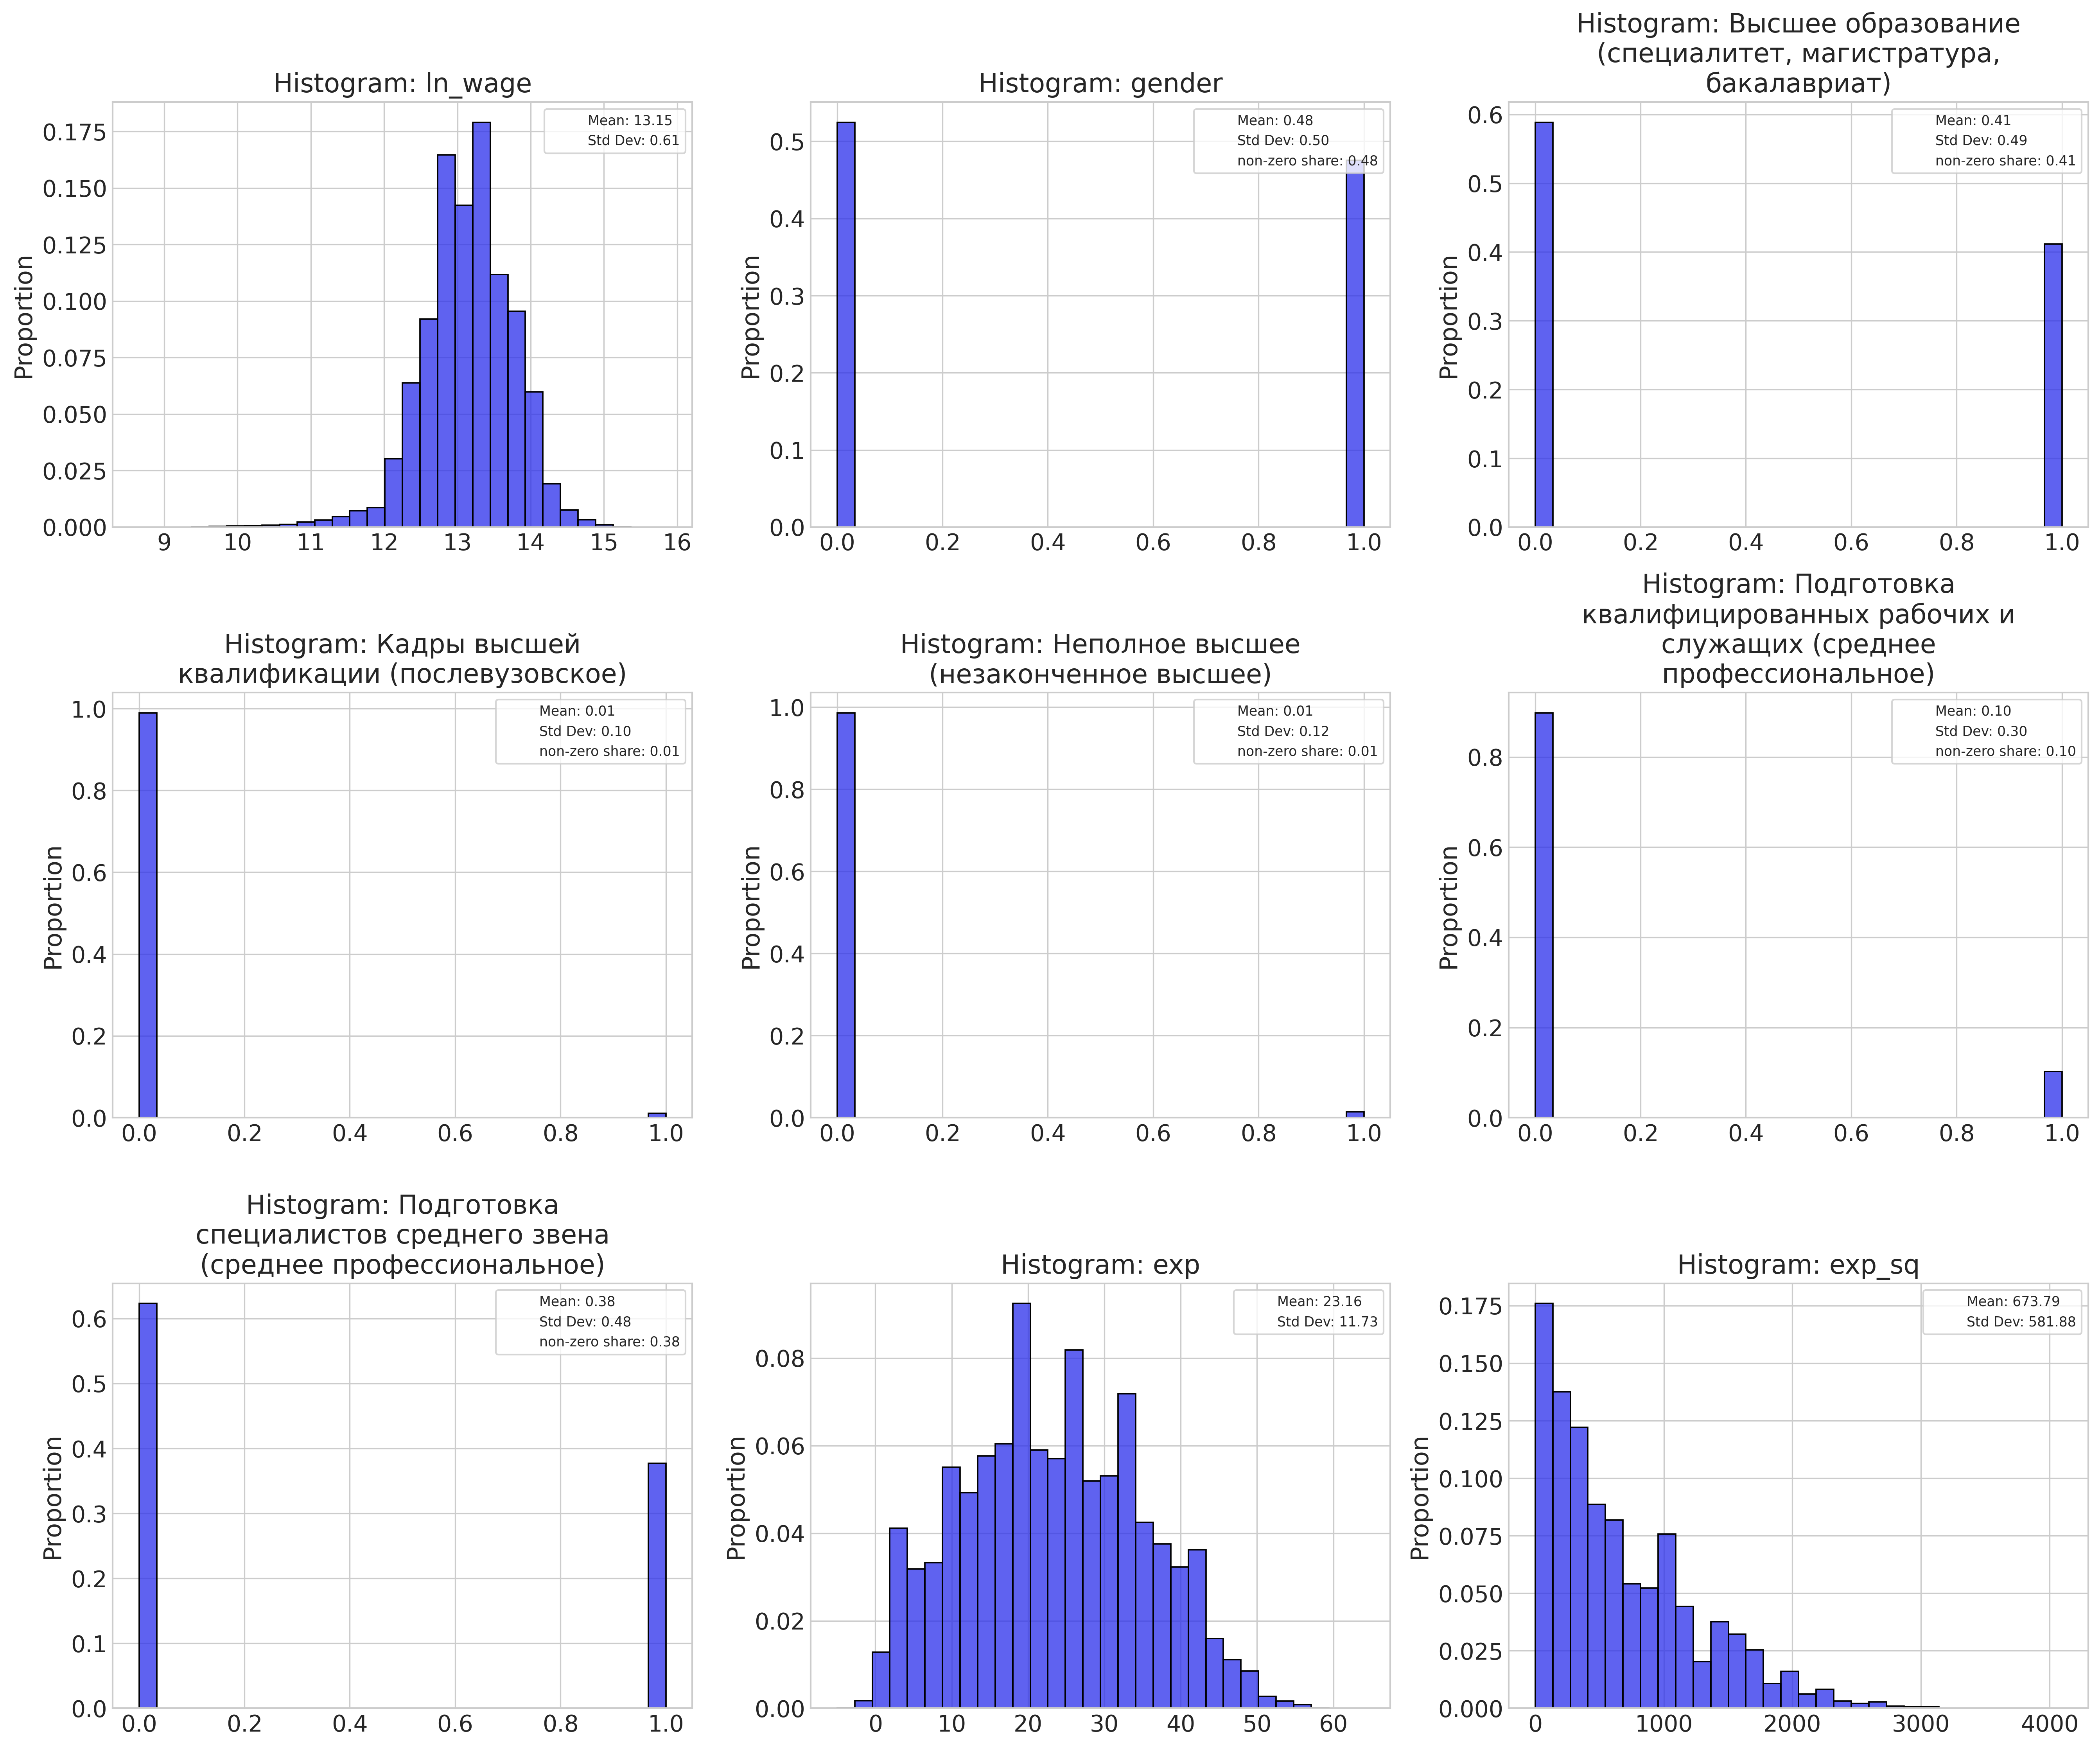

In [20]:
import textwrap # For handling long column names

cols = data.columns
n = len(cols)

figs, axes  = plt.subplots(3, 3, dpi=300, figsize=(18, 15))

axes = axes.flatten()
for i in range(n):
    ax = axes[i]
    col_vars = data[cols[i]]
    
    wrapped_name = textwrap.fill(col_vars.name, width=40)
    stats = {'Mean' : col_vars.mean(), 'Std Dev' : col_vars.std()}
    if col_vars.name in indicator_cols: 
        stats['non-zero share'] = (col_vars != 0.).mean()
    
    labels = [f'{k}: {v:.2f}' for k, v in stats.items()]
    handles = [mpatches.Rectangle((0, 0), 0, 0, color='none', label=l) for l in labels]
    
    ax.legend(handles=handles, labels=labels, loc='upper right', fontsize='small', frameon=True)
    
    sns.histplot(col_vars, stat='proportion',  ax=ax, bins=30)
    ax.set_xlabel('') 
    ax.set_title(textwrap.fill(f'Histogram: {wrapped_name}', width=30))
    ax.grid(True)

plt.tight_layout()
plt.show()

### Выбор априорных распределений для параметров

В рамках байесовского моделирования необходимо определить априорные распределения для параметров модели. 


**Распределения для $\rho$**

Минцеровская регрессия предполагает, что логарифм доходов линейно зависит от степени образования. При потенцировании модель становится мультипликативной, а значит, если $\rho$ > 0 , образование повышает доходы относительно некоторого бейслайна. Этим бейслайном выступает доход респондента со средним полным образованием (11 классов). Если $\rho < 0$, то образование снижает доходы относительно бейслайна. Исходя из этих свойств можно наложить условия на априорное распределение параметров $\rho$:

1) $\rho \in \mathbb{R}$. Так как отдача от образования хоть и подтверждается эмпирическими исследованиями, изменение доходов образованных людей формально не ограничено и в теории может отличаться от бейслайна как угодно. 

2) $E[\rho] > 0$. Как было указано в п.1, есть эмпрические подтверждения того, что получение образования в среднем по миру положительно влияет на доходы. 

3) $Var[\rho]$ небольшая. Так как речь идет о моделировании логарифма доходов, плотность за пределами диапазона [0, 1] должна быть несущественной. Во-первых, в п.2 указано, что негативное влияние образования на доходы маловероятно. Во-вторых, отдача от образования также не может быть слишком высокой и давать многократный прирост доходов. 

Исходя из перечисленных выше аргументов, подходящим можно считать нормальное распределение с параметрами  $ \rho_i \sim N(0.5, 0.2^2).$

**Распределение для $\alpha_0$**

Так как это бейслайн, выберем также нормальное распределение с небольшой дисперсией: $\alpha_0 \sim N(13, 1)$.

**Распределение для $\alpha_1$**

Данный параметр показывает влияние на доходы в зависимости от пола респондента. Руководствуясь теми же принципами, что и для $\rho$, положим $\alpha_1 \sim N(0.3, 0.2).$

**Распределение для $ E_1, E_2$**

Данные параметры показывают влияние на доходы в зависимости от опыта и квадрата опыта респондента. Согласно исследованиям, квадратичная зависимость дохода от опыта прослеживается, в какой-то момент избыточный опыт снижает доходы. Отсюда следует, что парабола перевернута, то есть логично предположить, что $E_2 < 0$. 
Тогда зададим $E_2 \sim N(-0.03, 0.003 ^2)$, $E_1 \sim N(0, 0.003 ^2)$ * 


*Пока оставил околонулевую дисперсию, в ином случае prior predictive очень сильные выбросы имел 












#### Prior predictive

Sampling: [alpha_0, alpha_1, beta_1, beta_2, rho, sigma, y_obs]


<Axes: xlabel='y_obs'>

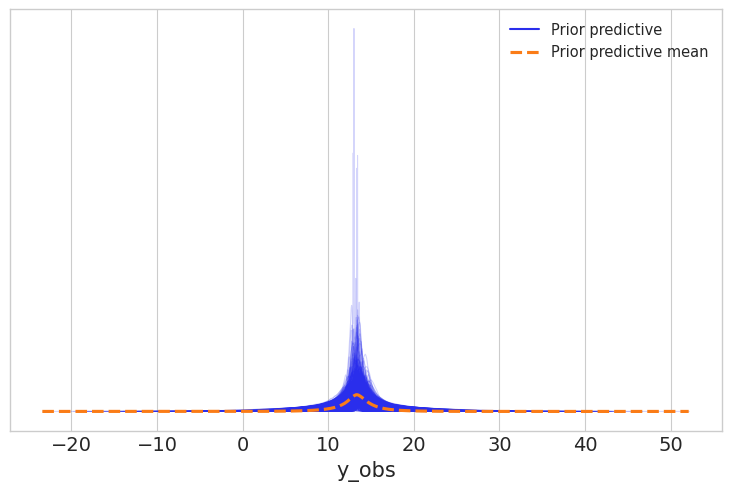

In [21]:
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import numpy as np

az.style.use("arviz-whitegrid")
X = data.drop(columns="ln_wage")

# Gender 
G = X['gender'].values
L = X[educuation_cols].values
E = X[['exp', 'exp_sq']].values 


# Indicator variables of education 
y = data["ln_wage"].to_numpy(dtype=float)
w = np.asarray(weights, dtype=float).reshape(-1)
w = w / w.mean()

N = 1000
with pm.Model() as m:
    
    X_data = pm.Data("X", X)
    G_data = pm.Data("G", G)
    L_data = pm.Data("L", L)
    E_data = pm.Data("E", E)

    y_data = pm.Data("y", y)
    w_data = pm.Data("w", w)
    
    # Intercept 
    alpha_0 = pm.Normal("alpha_0", 13, 0.2)

    # alpha for gender slope
    alpha_1 = pm.Normal("alpha_1", 0.3, 0.2)

    # rho for education slope
    rho  = pm.Normal("rho", 0.3, 0.4, shape=L.shape[1])

    #betas for experience slope
    beta_1 = pm.Normal("beta_1", 0, 0.003)
    beta_2 = pm.Normal("beta_2", 0, 0.003)

    betas = pt.stack([beta_1, beta_2])
    # error 
    sigma = pm.HalfNormal("sigma", 1.0)

    mu = pm.Deterministic("mu", alpha_0 
                                + pm.math.dot(G_data, alpha_1) 
                                + pm.math.dot(L_data, rho) 
                                + pm.math.dot(E_data, betas)
                                )

    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)
    idata = pm.sample_prior_predictive(N)

az.plot_ppc(
    idata,
    group="prior",

)
# az.plot_dist(values=idata.prior_predictive.y_obs, quantiles=[0.5, 0.6])
# az.summary(idata, hdi_prob=0.95)

#### Posterior

In [ ]:
with pm.Model() as m:

    X_data = pm.Data("X", X)
    G_data = pm.Data("G", G)
    L_data = pm.Data("L", L)
    E_data = pm.Data("E", E)

    y_data = pm.Data("y", y)
    w_data = pm.Data("w", w)
    
    # Intercept 
    alpha_0 = pm.Normal("alpha_0", 13, 0.2)

    # alpha for gender slope
    alpha_1 = pm.Normal("alpha_1", 0.3, 0.2)

    # rho for education slope
    rho  = pm.Normal("rho", 0.3, 0.4, shape=L.shape[1])

    #betas for experience slope
    beta_1 = pm.Normal("beta_1", 0, 0.003)
    beta_2 = pm.Normal("beta_2", 0, 0.003)

    betas = pt.stack([beta_1, beta_2])
    # error 
    sigma = pm.HalfNormal("sigma", 1.0)

    mu = pm.Deterministic("mu", alpha_0 
                                + pm.math.dot(G_data, alpha_1) 
                                + pm.math.dot(L_data, rho) 
                                + pm.math.dot(E_data, betas)
                                )
    
    
    # Weighted log-likelihood 
    logp = pm.logp(pm.Normal.dist(mu=mu, sigma=sigma), y_data)
    pm.Potential("wll", w_data * logp)

    idata = pm.sample(
        tune=1000,
        draws=1000,
        chains=2,             
        cores=2,
        target_accept=0.95,
        random_seed=123,
        nuts_sampler="nutpie"
    )

az.summary(idata)
az.plot_energy(idata)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.20,15
,2000,0,0.20,31


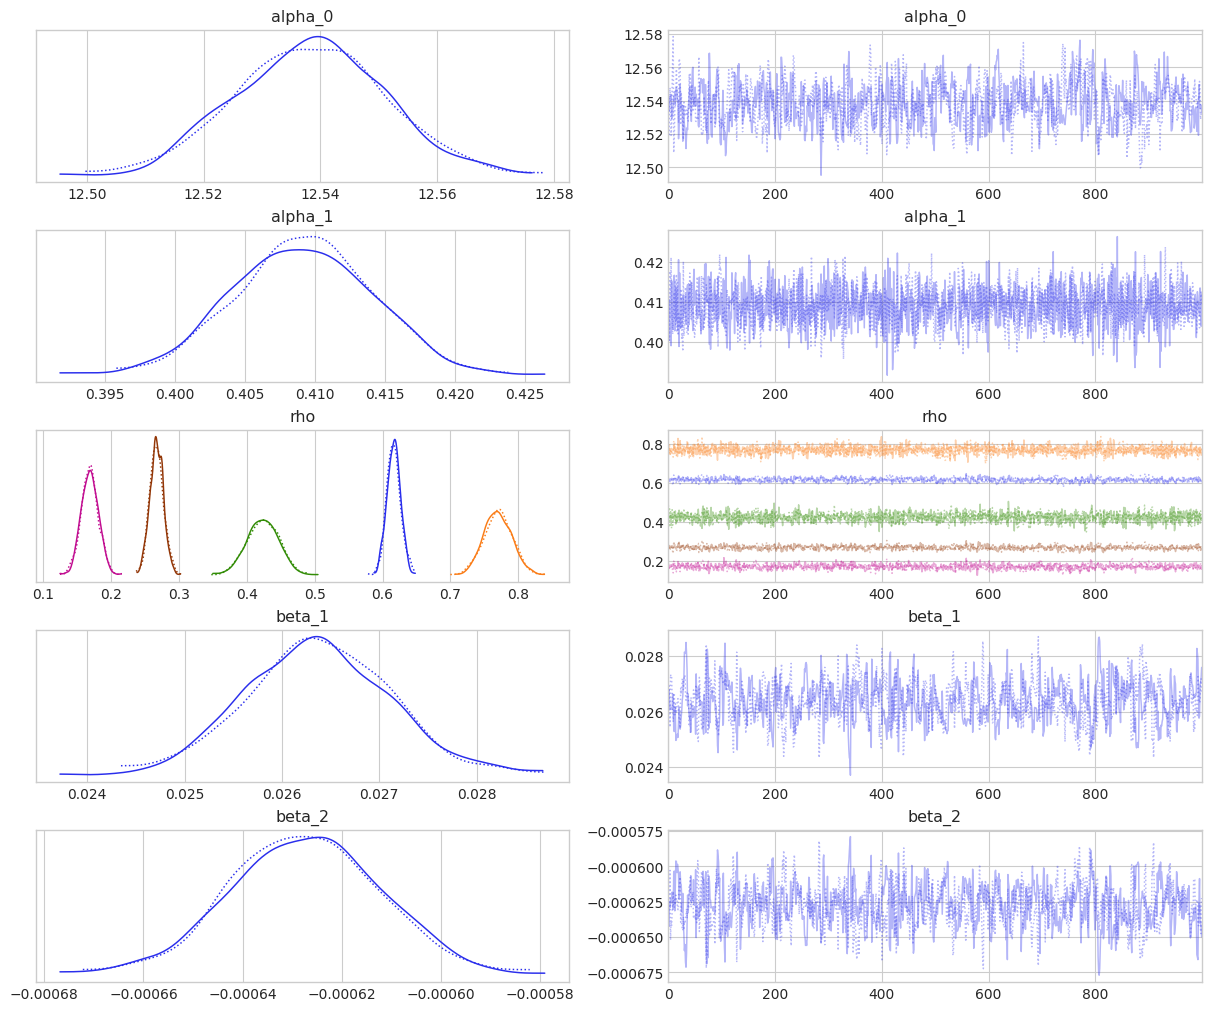

In [ ]:
az.plot_trace(idata, var_names=['alpha_0', 'alpha_1', 'rho', 'beta_1', 'beta_2']);